# Electronic Band Structure with VASP

A band structure calculation samples the available electronic states along a special high symmetry path through k-point space. We need this to determine the band gap.

`solphin` provides methods to write input files and read output files to calculate this using VASP.

#### Pre-requisites:
* Structural Relaxation

## Calculation

1) Import the necessary libraries.

In [ ]:
import solphin.band_structure as band_structure
import solphin.vasp_inputs as vasp_inputs

2) Define our computational regime. This should be the same regime used to relax the structure.

In [2]:
functional = 'HSE06'  # The DFT functional
encut = 450           # Plane-wave basis set energy cutoff
kspacing = 0.2        # k-point sampling density

3) Load the optimised atomic structure from a previous relaxation. Here we read from the bundled test data.

In [3]:
structure = vasp_inputs.read_structure_pmg("../tests/data/Cu2GeS3/Relax/CONTCAR")

4) We have to sample points along the high symmetry path in k-space. There are different choices of definition for this path, but all require a "canonical" orientation of the structure with respect to the axes. Here we ensure the correct structure and use the Bradley-Cracknell path.

In [4]:
canonical_structure, band_path = band_structure.generate_band_structure_path(structure=structure, definition="bradcrack")

Generated high-symmetry path of 239 k-points


5) Write the input files.

* If using a hybrid functional, we need to provide the k-points that would be used in a standard DOS/Optics calculation in addition to the high-symmetry path. You can point to the optics calculation if you have already done it, or generate the necessary file by a quick "dry run" of VASP.


* If using a GGA functional, you need to provide the charge density (`CHGCAR`) from a standard DOS/Optics calculation.


* If using a hybrid functional, the computational cost can be large. Fortunately, each k-point can be solved independently, so we provide the option to split the calculation up.


* Here, we use a hybrid functional and split the calculation into 10 parts. We write to `workdir/optics` which is untracked, and can be used to try out these tutorials. This requires having set up your VASP `POTCAR`s with `pymatgen`.

In [5]:
band_structure.write_band_structure_calculation(
    structure=canonical_structure,
    kpath=band_path,
    band_directory="workdir/band",
    functional=functional,
    splits=10,
    scf_kpoints="../tests/data/Cu2GeS3/OPT_hybrid/IBZKPT",
    user_incar_settings={"ENCUT": encut})

## Analysis

1) Import the necessary libraries

In [10]:
import matplotlib.pyplot as plt

import solphin.band_structure as band_structure

%matplotlib inline

2) Load the band structure from its splits.

In [8]:
bs = band_structure.get_band_structure("../tests/data/Cu2GeS3/BAND_SP_HDFT", splits=7)

3) Plot the band structure

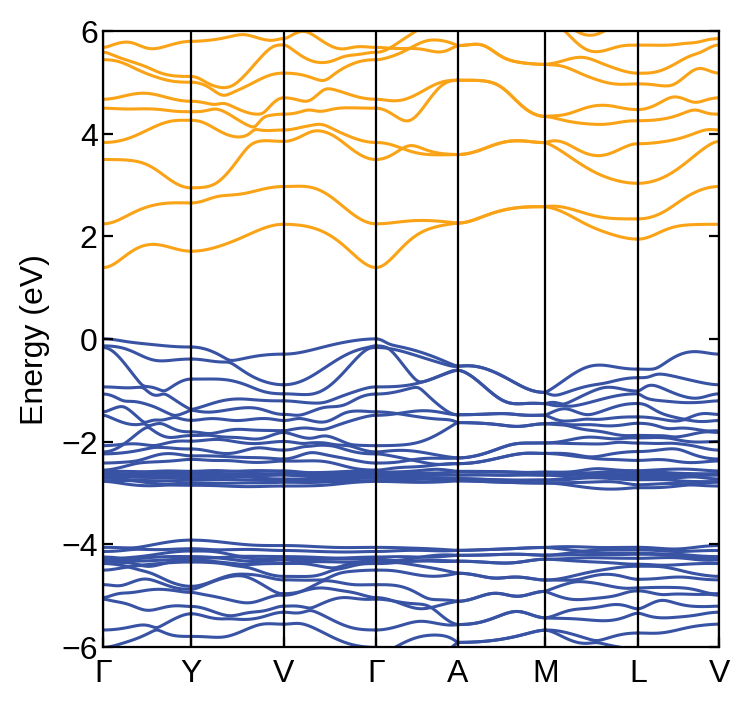

In [12]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)
_ = band_structure.plot_band_structure(bs, plt, ymin=-6, ymax=6)

4) Extract the band gap and report it

In [15]:
fundamental_gap = bs.get_band_gap()
E_gap_fundamental = fundamental_gap["energy"]
E_gap_direct = bs.get_direct_band_gap()
print(f"Band Gap = {E_gap_fundamental:.2f} eV, {fundamental_gap['transition']}")

Band Gap = 1.39 eV, \Gamma-\Gamma
